In [51]:
import pandas as pd
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MaxAbsScaler
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [52]:
# link of the dataset
# https://huggingface.co/datasets/arbml/ashaar/tree/main/data
df = pd.read_parquet('../datasets/train-00000-of-00002.parquet')

In [53]:
# to remove rows with empty meter
dff = df[df["poem meter"].notna()]

# to remove rows with empty verses
dfff = dff[dff["poem verses"].notna()]

In [54]:
# view of number of each baher in the dataset
dfff["poem meter"].value_counts()

poem meter
بحر الطويل          14756
الطويل              12758
الكامل               9998
بحر الكامل           8854
بحر البسيط           8306
                    ...  
بحر أحذ المديد          1
بحر مخلع السريع         1
بحر مشطور السريع        1
بحر منهوك الكامل        1
عدة أبحر                1
Name: count, Length: 99, dtype: int64

In [55]:
# view of one verse from the dataset
' '.join(dfff["poem verses"][0].tolist())

'أَصبَحَ المُلك لِلَّذي فَطر الخَل قَ بِتَقديرٍ للعَزيز العَليمِ غافر الذَنب للمسيءِ بِعَفوٍ قابل التَوب ذي العَطاء العَميمِ مُرسل المُصطَفى البَشير إِلَينا رَحمة مِنهُ بِالكَلام القَديمِ رَبَنا رَبّنا إِلَيكَ أَنينا فَأَجرنا مِن حَر نار الجَحيمِ وَاكفِنا شَرّ ما نَخاف بِلُطفٍ يا عَظيماً يَرجى لِكُل عَظيمِ وَتَقبل أَعمالَنا وَاعفُ عَنا وَأَنلنا دُخول دار النَعيمِ بِنَبي بَعثَتهُ فَهَدانا لِصِراط مِن الهُدى مُستَقيمِ وَبِمَن نَحنُ في حِماهُ مَدى الدَهر أَخيهِ يَحيى الحصور الكَريمِ أَدرك أَدرك قَوماً أَتوا بافتقار وَاِنكِسار وَمَدمَع مَسجومِ شَهدت أَرواحَهُم أَنكَ اللَهُ وَجاءوا بِكُل قَلبٍ سَليم'

In [56]:
# to keep only bahers that have more than 3000 samples
data = dfff
dfs = pd.DataFrame(data)
column_name = 'poem meter'
min_count = 3000
counts = dfs[column_name].value_counts()
frequent_values = counts[counts > min_count].index
filtered_df = dfs[dfs[column_name].isin(frequent_values)]

In [57]:
# number of bahers on filtered dataset
filtered_df["poem meter"].nunique()

12

In [58]:
# to get only 3000 samples of each baher and remove the rest
df_sampled = filtered_df.groupby('poem meter').head(2000)

In [59]:
# to remove tshkeel from verses
verses = []
for x in df_sampled["poem verses"]:
    # text = re.sub(r'[\u064B-\u065F]', '', str(' '.join(x.tolist())))
    text = str(' '.join(x.tolist()))
    verses.append(text)

In [60]:
verses

['أَصبَحَ المُلك لِلَّذي فَطر الخَل قَ بِتَقديرٍ للعَزيز العَليمِ غافر الذَنب للمسيءِ بِعَفوٍ قابل التَوب ذي العَطاء العَميمِ مُرسل المُصطَفى البَشير إِلَينا رَحمة مِنهُ بِالكَلام القَديمِ رَبَنا رَبّنا إِلَيكَ أَنينا فَأَجرنا مِن حَر نار الجَحيمِ وَاكفِنا شَرّ ما نَخاف بِلُطفٍ يا عَظيماً يَرجى لِكُل عَظيمِ وَتَقبل أَعمالَنا وَاعفُ عَنا وَأَنلنا دُخول دار النَعيمِ بِنَبي بَعثَتهُ فَهَدانا لِصِراط مِن الهُدى مُستَقيمِ وَبِمَن نَحنُ في حِماهُ مَدى الدَهر أَخيهِ يَحيى الحصور الكَريمِ أَدرك أَدرك قَوماً أَتوا بافتقار وَاِنكِسار وَمَدمَع مَسجومِ شَهدت أَرواحَهُم أَنكَ اللَهُ وَجاءوا بِكُل قَلبٍ سَليم',
 'العَبد عَبدك يا مَن أَنتَ سَيدهُ وَلَيسَ غَيركَ في الأَوصابِ يُنجدهُ أَنتَ الَّذي لِسَبيل الخَير تُرشِدُهُ مالي سَواكَ رَسول اللَهِ أَقصِدُهُ وَمِن جَنابِكَ في الدارين مُلتَمسي لا أَستَعين بِأَنصار وَلا عَدَد وَلا بِجاه وَلا مال وَلا وَلَد بَل أَنتَ أَنتَ الرَجا يا خَير مُعتَمَدِ لَولاكِ ما خُلِقَت روحي وَلا جَسَدي وَلا حَياتي وَلا نَفسي وَلا نَفسي أَنت الَّذي حازَ رايات العُلى وَعَلى مَتن 

In [61]:
len(verses)

24000

In [62]:
df_sampled["poem meter"]

0        بحر الخفيف
2        بحر البسيط
3        بحر الكامل
4        بحر الوافر
5        بحر الكامل
            ...    
95432        الوافر
95441        الوافر
95468        الوافر
95487        الوافر
95494        الوافر
Name: poem meter, Length: 24000, dtype: object

In [63]:
fff = df_sampled['poem meter'].astype('category').cat.codes

In [95]:
df_sampled["poem meter"].value_counts()

poem meter
بحر الخفيف    2000
بحر البسيط    2000
بحر الكامل    2000
بحر الوافر    2000
بحر الطويل    2000
بحر السريع    2000
عموديه        2000
الخفيف        2000
الكامل        2000
الطويل        2000
البسيط        2000
الوافر        2000
Name: count, dtype: int64

In [93]:
fff[1315]

11

In [94]:
df_sampled['poem meter'][1315]

'عموديه'

In [83]:
df_sampled['poem meter'].astype('category').cat

In [67]:
# ====================================================
# FINE-TUNING WITH VALIDATION - SIMPLE VERSION
# ====================================================

# 1. Install
# !pip install -q transformers datasets pandas sklearn

# 2. Imports
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, classification_report

# 3. Your Data
texts = verses  # 100 samples

labels = fff

# 4. Split into train and validation (80/20)
train_texts, val_texts, train_labels, val_labels = train_test_split(
    texts, labels, 
    test_size=0.2,  # 20% for validation
    random_state=42,  # For reproducibility
    stratify=labels  # Maintain class distribution
)

print(f"Train samples: {len(train_texts)}")
print(f"Validation samples: {len(val_texts)}")

# 5. Create datasets
train_dataset = Dataset.from_dict({"text": train_texts, "label": train_labels})
val_dataset = Dataset.from_dict({"text": val_texts, "label": val_labels})

# 6. Load tokenizer and model
model_name = "../arapoembert_len32_baseline/model"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Fix padding token
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForSequenceClassification.from_pretrained(
    model_name, 
    num_labels=len(set(labels)),
    ignore_mismatched_sizes=True
)

# 7. Tokenize function
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=32
    )

# Tokenize both datasets
train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)

# Remove text column
train_dataset = train_dataset.remove_columns(["text"])
val_dataset = val_dataset.remove_columns(["text"])

# 8. Define metrics function
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    
    return {
        'accuracy': accuracy_score(labels, predictions),
        'f1_macro': f1_score(labels, predictions, average='macro'),
        'f1_weighted': f1_score(labels, predictions, average='weighted'),
    }

# 9. Training arguments with validation
training_args = TrainingArguments(
    output_dir="./results_tw_tw_tw",
    num_train_epochs=2,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,  # Batch size for validation
    warmup_steps=100,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=10,
    eval_strategy="epoch",  # Evaluate at the end of each epoch
    save_strategy="epoch",         # Save at each epoch
    load_best_model_at_end=True,   # Load the best model when finished
    metric_for_best_model="f1_macro",  # Which metric to use for best model
    greater_is_better=True,         # Higher F1 is better
    save_total_limit=2,             # Keep only 2 best models
)

# 10. Create trainer with validation dataset
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,  # Add validation dataset
    compute_metrics=compute_metrics,
)

# 11. Train
print("Starting training...")
trainer.train()

# 12. Final evaluation
print("\n" + "="*50)
print("FINAL VALIDATION RESULTS")
print("="*50)
eval_results = trainer.evaluate()
for key, value in eval_results.items():
    print(f"{key}: {value:.4f}")

Train samples: 19200
Validation samples: 4800


Loading weights: 100%|██████████| 169/169 [00:00<00:00, 771.31it/s, Materializing param=classifier.weight]                                     
BertForSequenceClassification LOAD REPORT from: ../arapoembert_len32_baseline/model
Key               | Status   |                                                                                        
------------------+----------+----------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([4]) vs model:torch.Size([12])          
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([4, 768]) vs model:torch.Size([12, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.
Map: 100%|██████████| 4800/4800 [00:00<00:00, 7350.54 examples/s]
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Starting training...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,1.873709,1.861777,0.186667,0.085267,0.085267
2,1.840154,1.772291,0.222917,0.138331,0.138331


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.62it/s]
There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer


FINAL VALIDATION RESULTS


eval_loss: 1.7723
eval_accuracy: 0.2229
eval_f1_macro: 0.1383
eval_f1_weighted: 0.1383
eval_runtime: 4.3057
eval_samples_per_second: 1114.8060
eval_steps_per_second: 139.3510
epoch: 2.0000


In [76]:
print("Starting training...")
trainer.train()

# 12. Final evaluation
print("\n" + "="*50)
print("FINAL VALIDATION RESULTS")
print("="*50)
eval_results = trainer.evaluate()
for key, value in eval_results.items():
    print(f"{key}: {value:.4f}")

Starting training...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.764351,1.124461,0.774167,0.761142,0.761142
2,0.320564,1.010668,0.815208,0.806996,0.806996


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.43it/s]
There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer


FINAL VALIDATION RESULTS


eval_loss: 1.0107
eval_accuracy: 0.8152
eval_f1_macro: 0.8070
eval_f1_weighted: 0.8070
eval_runtime: 4.9475
eval_samples_per_second: 970.1800
eval_steps_per_second: 121.2720
epoch: 2.0000


In [ ]:
model.save_pretrained()

In [ ]:
# to convert verses to their vectory representation
vectorizer = TfidfVectorizer(ngram_range=(1,10),max_features=50000)
X = vectorizer.fit_transform(verses)

KeyboardInterrupt: 

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, df_sampled["poem meter"], test_size=0.2, random_state=42)

In [ ]:
# train on naive bayes classifier after scaling the vectors
clf = Pipeline([
    ('scaler', MaxAbsScaler()),
    ('clf', MultinomialNB()),
])

clf.fit(X_train, y_train)

Pipeline(steps=[('scaler', MaxAbsScaler()), ('clf', MultinomialNB())])

In [ ]:
accuracy = clf.score(X_train, y_train)
print(f"Train Accuracy: {accuracy * 100:.2f}%")
accuracy = clf.score(X_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

Train Accuracy: 81.34%
Test Accuracy: 43.92%


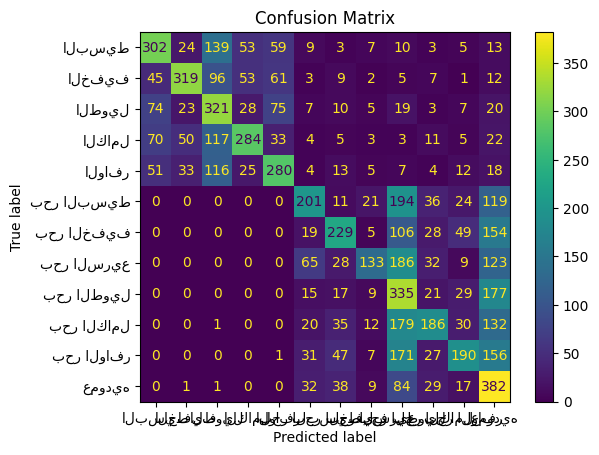

In [ ]:
# to view confusion matrix
y_pred = clf.predict(X_test)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# ====================================================
# SIMPLE CONFUSION MATRIX
# ====================================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# After training, get predictions
# predictions = trainer.predict(val_dataset)
y_pred = y_pred
y_true = y_test

# Define your class names
class_names = ['Classical', 'Modern', 'Nabati', 'Free Verse']  # Replace with your actual classes

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix - Poetry Classification', fontsize=14)
plt.tight_layout()
plt.show()

# Print accuracy
accuracy = np.sum(np.array(y_true) == np.array(y_pred)) / len(y_true)
print(f"Overall Accuracy: {accuracy:.2%}")

NameError: name 'y_pred' is not defined

In [79]:
y_true

array([ 2,  2,  7, ...,  6, 11,  2])

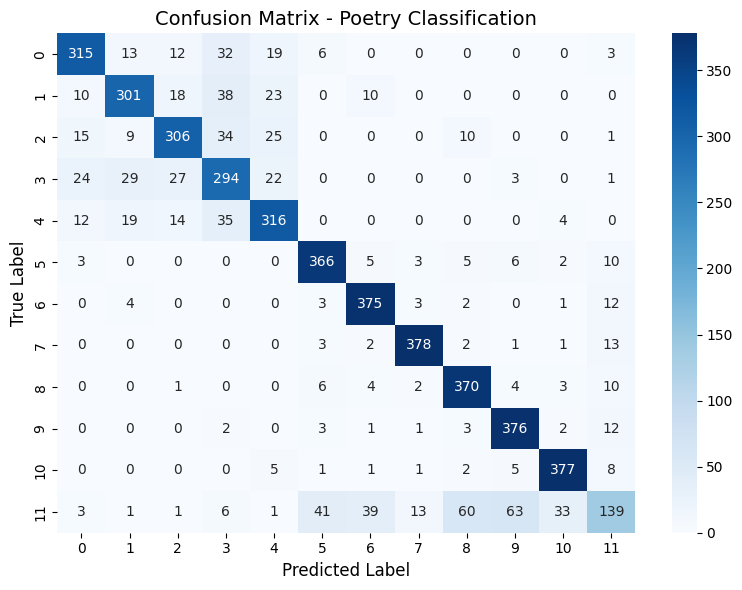

Overall Accuracy: 81.52%


In [ ]:
# ====================================================
# SIMPLE CONFUSION MATRIX
# ====================================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# After training, get predictions
predictions = trainer.predict(val_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

# Define your class names
# class_names = ['Classical', 'Modern', 'Nabati', 'Free Verse']  # Replace with your actual classes

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            )
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix - Poetry Classification', fontsize=14)
plt.tight_layout()
plt.show()

# Print accuracy
accuracy = np.sum(np.array(y_true) == np.array(y_pred)) / len(y_true)
print(f"Overall Accuracy: {accuracy:.2%}")

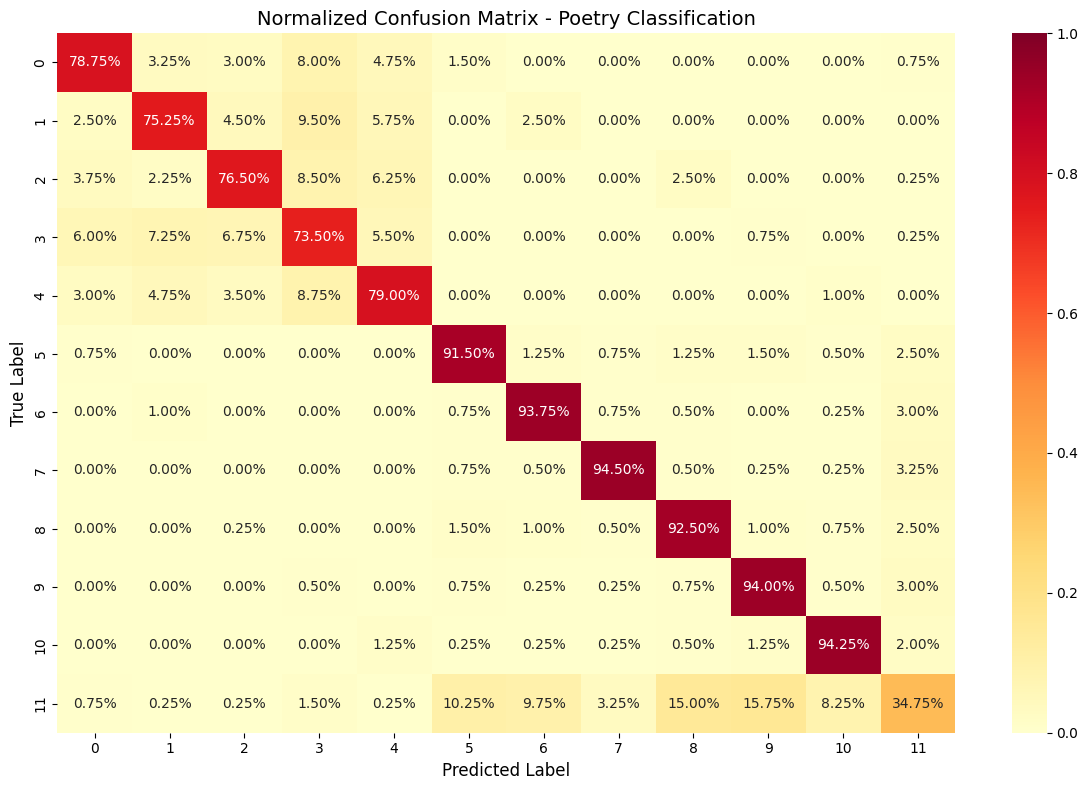

In [78]:
# ====================================================
# NORMALIZED CONFUSION MATRIX (Shows percentages)
# ====================================================

# Normalize by row (true labels)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(12, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='YlOrRd',
            
            vmin=0, vmax=1)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Normalized Confusion Matrix - Poetry Classification', fontsize=14)
plt.tight_layout()
plt.show()

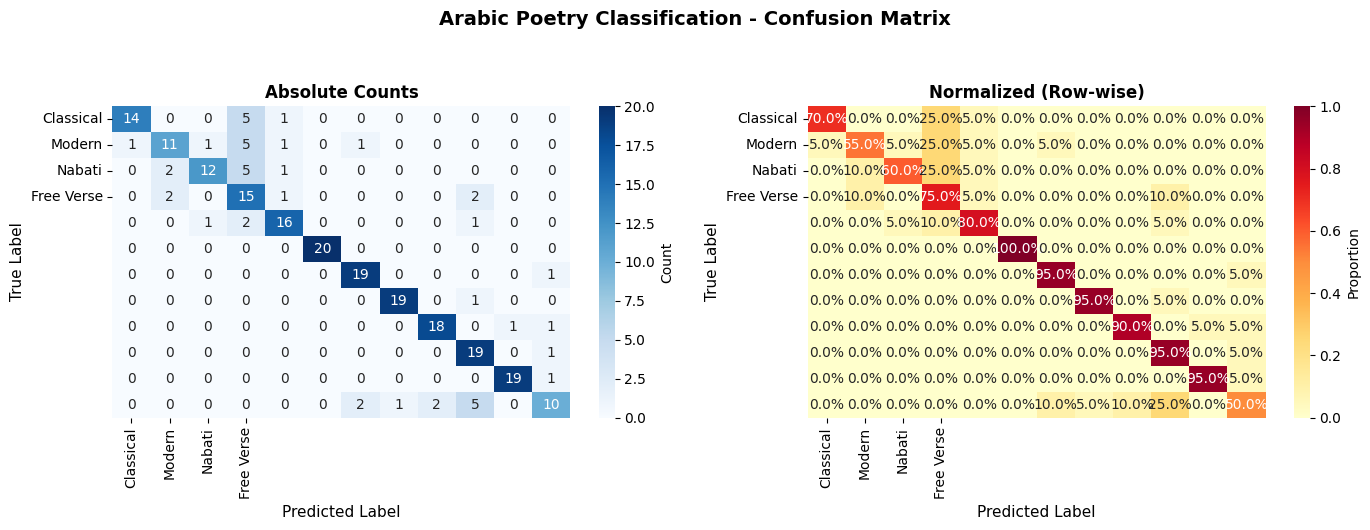


📊 Overall Accuracy: 80.00%

📈 Per-class Metrics:

Classical:
  Accuracy: 70.00%
  Precision: 93.33%
  Recall: 70.00%
  F1-Score: 80.00%

Modern:
  Accuracy: 55.00%
  Precision: 73.33%
  Recall: 55.00%
  F1-Score: 62.86%

Nabati:
  Accuracy: 60.00%
  Precision: 85.71%
  Recall: 60.00%
  F1-Score: 70.59%

Free Verse:
  Accuracy: 75.00%
  Precision: 46.88%
  Recall: 75.00%
  F1-Score: 57.69%


In [ ]:
# # ====================================================
# # PUBLICATION-READY CONFUSION MATRIX
# # ====================================================

# def plot_confusion_matrix(y_true, y_pred, class_names, title='Confusion Matrix'):
#     """
#     Create a beautiful confusion matrix with multiple visualizations
#     """
#     # Compute confusion matrix
#     cm = confusion_matrix(y_true, y_pred)
#     cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
#     # Create figure with subplots
#     fig = plt.figure(figsize=(14, 5))
    
#     # 1. Absolute counts matrix
#     ax1 = plt.subplot(1, 2, 1)
#     sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
#                 xticklabels=class_names, yticklabels=class_names,
#                 cbar_kws={'label': 'Count'}, ax=ax1)
#     ax1.set_xlabel('Predicted Label', fontsize=11)
#     ax1.set_ylabel('True Label', fontsize=11)
#     ax1.set_title('Absolute Counts', fontsize=12, fontweight='bold')
    
#     # 2. Normalized matrix
#     ax2 = plt.subplot(1, 2, 2)
#     sns.heatmap(cm_norm, annot=True, fmt='.1%', cmap='YlOrRd',
#                 xticklabels=class_names, yticklabels=class_names,
#                 cbar_kws={'label': 'Proportion'}, ax=ax2, vmin=0, vmax=1)
#     ax2.set_xlabel('Predicted Label', fontsize=11)
#     ax2.set_ylabel('True Label', fontsize=11)
#     ax2.set_title('Normalized (Row-wise)', fontsize=12, fontweight='bold')
    
#     plt.suptitle(title, fontsize=14, fontweight='bold', y=1.05)
#     plt.tight_layout()
#     plt.show()
    
#     # Print metrics
#     accuracy = np.mean(np.array(y_true) == np.array(y_pred))
#     print(f"\n📊 Overall Accuracy: {accuracy:.2%}")
    
#     print("\n📈 Per-class Metrics:")
#     for i, name in enumerate(class_names):
#         acc = cm[i, i] / cm[i].sum() if cm[i].sum() > 0 else 0
#         precision = cm[i, i] / cm[:, i].sum() if cm[:, i].sum() > 0 else 0
#         recall = cm[i, i] / cm[i].sum() if cm[i].sum() > 0 else 0
#         f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        
#         print(f"\n{name}:")
#         print(f"  Accuracy: {acc:.2%}")
#         print(f"  Precision: {precision:.2%}")
#         print(f"  Recall: {recall:.2%}")
#         print(f"  F1-Score: {f1:.2%}")

# # Use it
# plot_confusion_matrix(y_true, y_pred, class_names, 
#                      title='Arabic Poetry Classification - Confusion Matrix')